In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 0.001
NUM_CLASSES = 43
IMG_SIZE = 32
DATA_DIR = './data'

Device: cuda


In [3]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = datasets.GTSRB(
    root=DATA_DIR,
    split='train',
    transform=transform,
    download=True
)

test_dataset = datasets.GTSRB(
    root=DATA_DIR,
    split='test',
    transform=transform,
    download=True
)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Train: 26640, Test: 12630


In [5]:
class CNN_PyTorch(nn.Module):
    def __init__(self, num_classes=43):
        super(CNN_PyTorch, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = CNN_PyTorch().to(device)

In [6]:
def train_model(model, train_loader, test_loader, epochs=EPOCHS, lr=LEARNING_RATE):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        test_loss = test_loss / len(test_loader)
        test_acc = 100 * correct / total
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        scheduler.step(test_loss)
        print(f'Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%')
    
    return history

print("\n--- Training PyTorch CNN ---")
start_time = time.time()
history = train_model(model, train_loader, test_loader, epochs=EPOCHS)
print(f"Training time: {time.time() - start_time:.2f}s")


--- Training PyTorch CNN ---
Epoch 1/15 | Train Loss: 2.2472 | Train Acc: 34.90% | Test Loss: 1.2106 | Test Acc: 62.73%
Epoch 2/15 | Train Loss: 0.6756 | Train Acc: 77.97% | Test Loss: 0.5133 | Test Acc: 85.12%
Epoch 3/15 | Train Loss: 0.2786 | Train Acc: 91.16% | Test Loss: 0.4289 | Test Acc: 87.78%
Epoch 4/15 | Train Loss: 0.1664 | Train Acc: 94.87% | Test Loss: 0.3976 | Test Acc: 89.52%
Epoch 5/15 | Train Loss: 0.1140 | Train Acc: 96.46% | Test Loss: 0.3310 | Test Acc: 90.90%
Epoch 6/15 | Train Loss: 0.0893 | Train Acc: 97.30% | Test Loss: 0.3116 | Test Acc: 91.87%
Epoch 7/15 | Train Loss: 0.0697 | Train Acc: 97.77% | Test Loss: 0.3559 | Test Acc: 91.77%
Epoch 8/15 | Train Loss: 0.0642 | Train Acc: 97.89% | Test Loss: 0.3672 | Test Acc: 91.60%
Epoch 9/15 | Train Loss: 0.0469 | Train Acc: 98.48% | Test Loss: 0.3404 | Test Acc: 92.45%
Epoch 10/15 | Train Loss: 0.0436 | Train Acc: 98.71% | Test Loss: 0.3741 | Test Acc: 92.20%
Epoch 11/15 | Train Loss: 0.0201 | Train Acc: 99.34% | Test

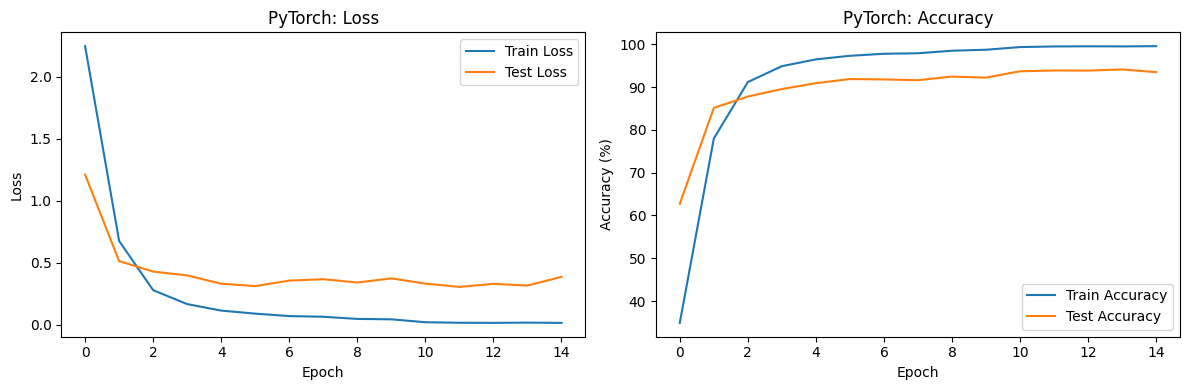

In [7]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('PyTorch: Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['test_acc'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('PyTorch: Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


--- Classification Report (PyTorch CNN) ---
              precision    recall  f1-score   support

           0     1.0000    0.5167    0.6813        60
           1     0.9604    0.9431    0.9516       720
           2     0.9090    0.9853    0.9456       750
           3     0.8986    0.9644    0.9303       450
           4     0.9812    0.9515    0.9662       660
           5     0.8022    0.9270    0.8601       630
           6     0.9762    0.8200    0.8913       150
           7     0.9612    0.8267    0.8889       450
           8     0.9325    0.8600    0.8948       450
           9     0.9734    0.9917    0.9825       480
          10     0.9834    0.9864    0.9849       660
          11     0.8725    0.9452    0.9074       420
          12     0.9895    0.9522    0.9705       690
          13     0.9755    0.9958    0.9856       720
          14     1.0000    0.9630    0.9811       270
          15     1.0000    0.9810    0.9904       210
          16     0.9930    0.9400   

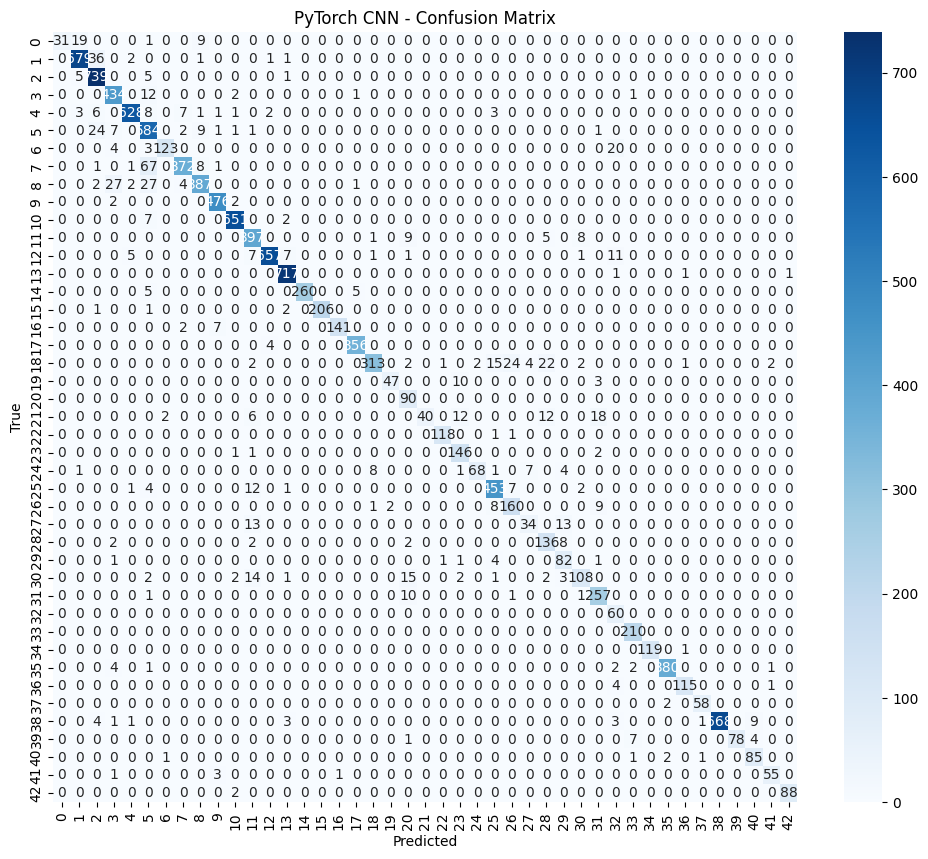

In [8]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n--- Classification Report (PyTorch CNN) ---")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('PyTorch CNN - Confusion Matrix')
plt.show()

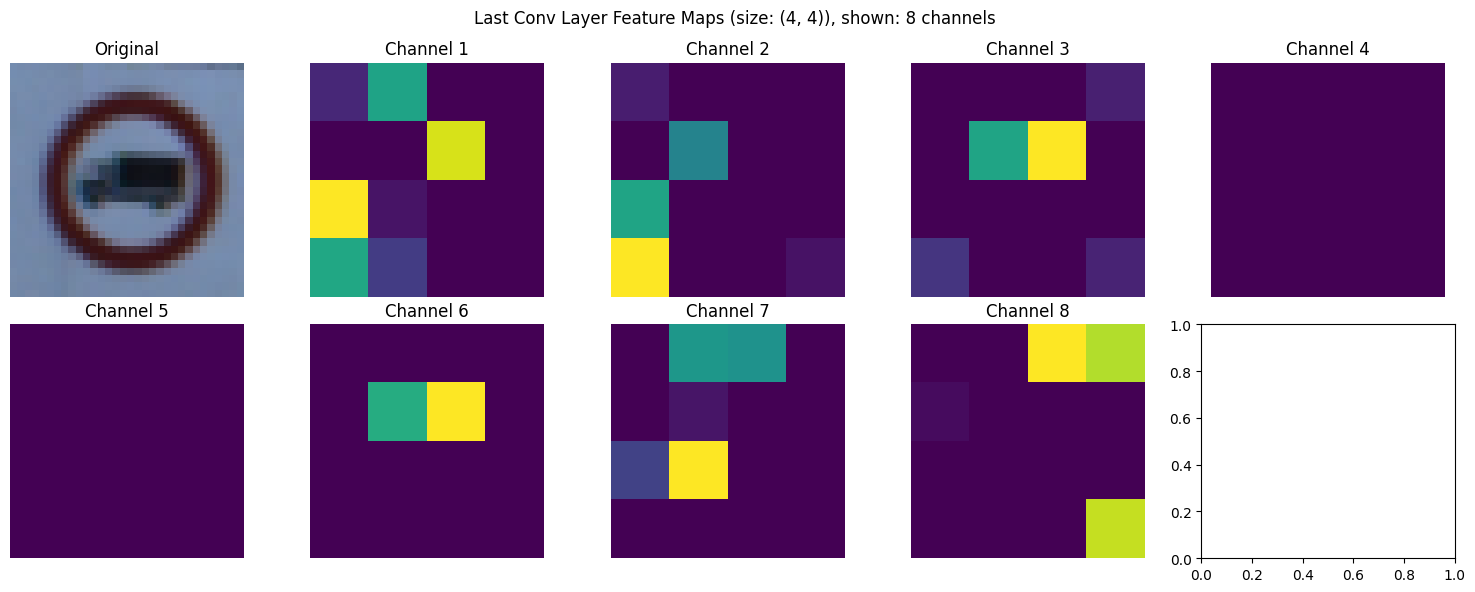

In [9]:
def get_last_feature_maps(model, image):
    model.eval()
    with torch.no_grad():
        x = image.unsqueeze(0).to(device)
        for layer in model.conv_layers:
            x = layer(x)
        return x.cpu().numpy()

def visualize_last_feature_maps(model, images, num_maps=8):
    features = get_last_feature_maps(model, images[0])
    fm = features[0]
    num_channels = fm.shape[0]
    n = min(num_maps, num_channels)
    
    img = images[0].cpu().numpy()
    img = np.transpose(img, (1, 2, 0))
    img = (img * 0.5) + 0.5
    
    fig, axes = plt.subplots(2, n//2 + 1, figsize=(15, 6))
    axes = axes.flatten()
    
    axes[0].imshow(img)
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    for i in range(n):
        fm_channel = fm[i, :, :]
        fm_channel = (fm_channel - fm_channel.min()) / (fm_channel.max() - fm_channel.min() + 1e-8)
        axes[i+1].imshow(fm_channel, cmap='viridis')
        axes[i+1].set_title(f'Channel {i+1}')
        axes[i+1].axis('off')
    
    plt.suptitle(f'Last Conv Layer Feature Maps (size: {fm.shape[1:]}), shown: {n} channels')
    plt.tight_layout()
    plt.show()

test_iter = iter(test_loader)
images, labels = next(test_iter)
visualize_last_feature_maps(model, images, num_maps=8)